Exploratory Data Analysis


import all libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 


Load dataset

In [3]:
df = pd.read_csv("F:\\Project\\Covid_Project\\data_analysis\\data\\covid_19_clean_complete.csv")

Analize thee dataset

In [4]:
df.head(10)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa
5,NaN,Antigua and Barbuda,17.06080,-61.796400,2020-01-22,0,0,0,0,Americas
6,NaN,Argentina,-38.41610,-63.616700,2020-01-22,0,0,0,0,Americas
7,NaN,Armenia,40.06910,45.038200,2020-01-22,0,0,0,0,Europe
8,Australian Capital Territory,Australia,-35.47350,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.86880,151.209300,2020-01-22,0,0,0,0,Western Pacific


check shape of dataset

In [5]:
df.shape

(49068, 10)

Check info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


Date column is in object format, so it needs to change be converted into datetime for proper date analysis

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

check the value_count every column

In [8]:
for i in df.columns:
    print(df[i].value_counts())

Province/State
Australian Capital Territory    188
Yunnan                          188
Mayotte                         188
Guadeloupe                      188
French Polynesia                188
                               ... 
Guizhou                         188
Guangxi                         188
Guangdong                       188
Gansu                           188
Saint Pierre and Miquelon       188
Name: count, Length: 78, dtype: int64
Country/Region
China             6204
Canada            2256
France            2068
United Kingdom    2068
Australia         1504
                  ... 
Holy See           188
Honduras           188
Hungary            188
Iceland            188
Lesotho            188
Name: count, Length: 187, dtype: int64
Lat
 52.939900    376
 33.939110    188
 12.169600    188
 52.132600    188
-40.900600    188
             ... 
 11.825100    188
 18.735700    188
-1.831200     188
 26.820553    188
-29.610000    188
Name: count, Length: 260, dtype: int64
Lon

Check null values of each column

In [9]:
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

check the percentage of null values

In [10]:
(df.isnull().sum()/df.shape[0])*100

Province/State    70.114943
Country/Region     0.000000
Lat                0.000000
Long               0.000000
Date               0.000000
Confirmed          0.000000
Deaths             0.000000
Recovered          0.000000
Active             0.000000
WHO Region         0.000000
dtype: float64

fill null values of Province/State column with the help of country column.

In [11]:

df['Province/State']=df['Province/State'].fillna(df['Country/Region'])

* The missing values in Province/State were replaced with the value of Country/Region to handle missing data.

Check duplicates of dataset

In [12]:
df.duplicated().sum()

np.int64(0)

* In this dataset there are no duplicate rows.

Show Statistics summary

In [13]:
df.describe()

,Lat,Long,Date,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,49068,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,2020-04-24 12:00:00,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
min,-51.796300,-135.000000,2020-01-22 00:00:00,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,2020-03-08 18:00:00,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,2020-04-24 12:00:00,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,2020-06-10 06:00:00,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,2020-07-27 00:00:00,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06
std,24.950320,70.442740,NaN,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04


The dataset contain 49068 records. Confirmed case  show a large variation, with a maximum of apporximately 4.29 million cases.Deaths, recovered and active cases also very significant across locations.The negative minimum value of active cases(-14)indicates a possible data anomaly.

Chcek outliers

In [14]:
for i in df.columns:
   if df[i].dtype !='object':
      q1=df[i].quantile(0.25)
      q3=df[i].quantile(0.75)

      iqr=q3-q1

      l=q1-1.5*iqr
      u=q3+1.5*iqr

      out=df[(df[i]<l)|(df[i]>u)]
      print(i,"-",len(out))

Lat - 376
Long - 0
Date - 0
Confirmed - 8817
Deaths - 9077
Recovered - 7936
Active - 8914


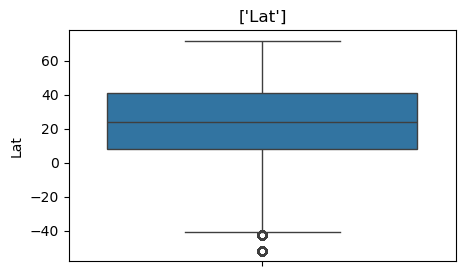

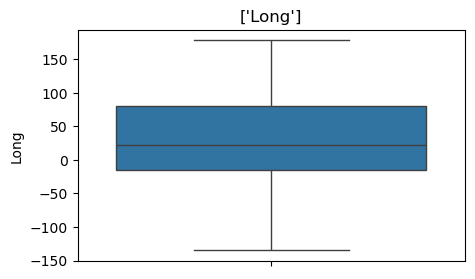

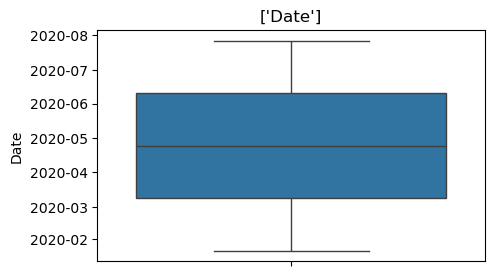

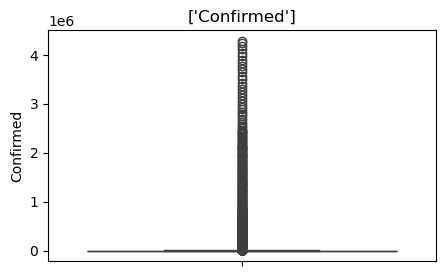

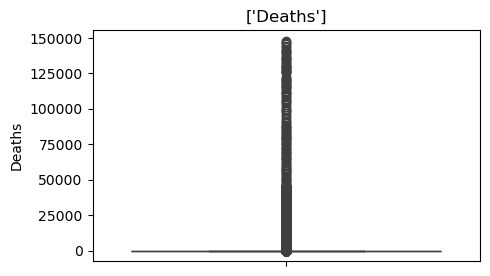

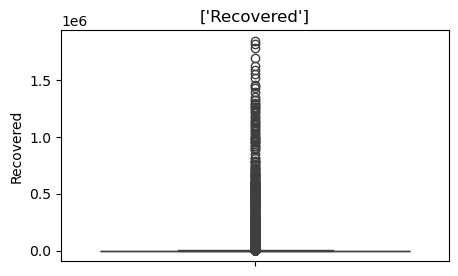

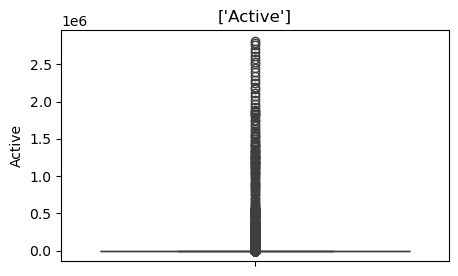

In [15]:
for i in df.columns:
    if df[i].dtype!="object":
        plt.figure(figsize=(5,3))
        sns.boxplot(data=df[i])
        plt.title([i])

Outliers were identified but they were retained because they represent genuine variation in COVID-19 cases rathan than data-entry errors.

# Visualization

visualize which country has the more confirmed cases.


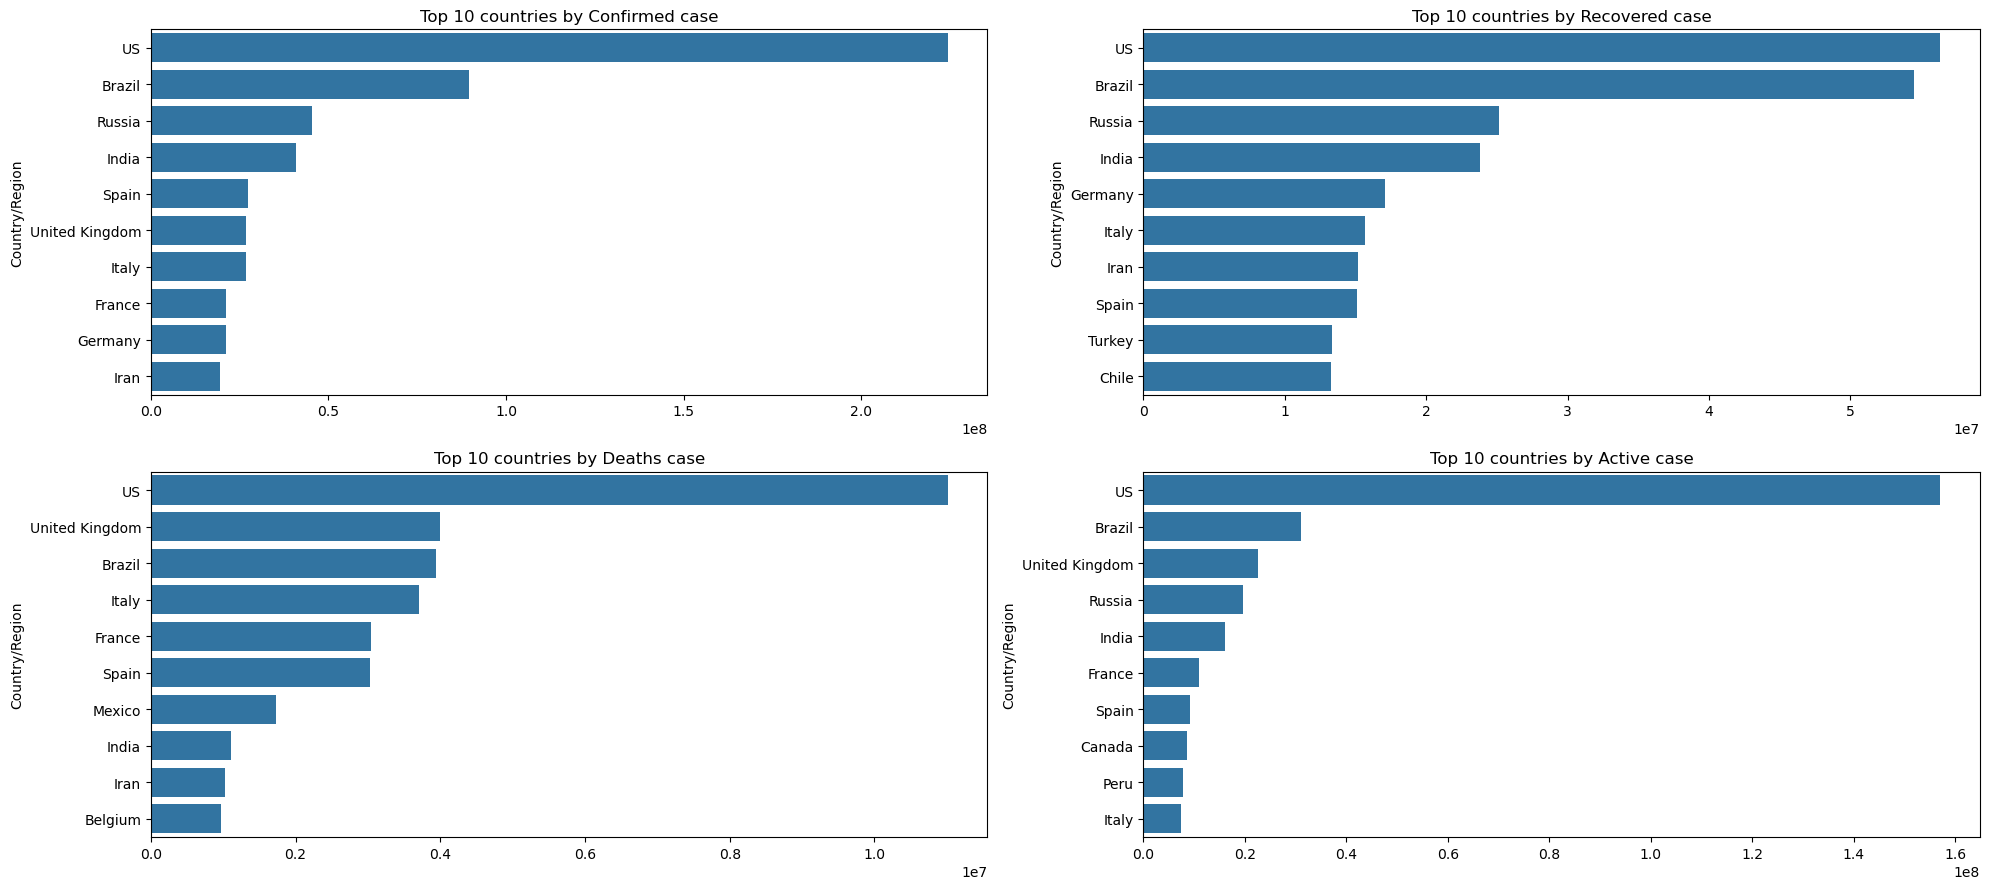

In [16]:
top10_confirmed= df.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False).head(10)
top10_deaths= df.groupby('Country/Region')['Deaths'].sum().sort_values(ascending=False).head(10)
top10_active= df.groupby('Country/Region')['Active'].sum().sort_values(ascending=False).head(10)
top10_Recovered= df.groupby('Country/Region')['Recovered'].sum().sort_values(ascending=False).head(10)


plt.subplots(2,2,figsize=(20,9))


plt.subplot(2,2,1)
sns.barplot(x=top10_confirmed.values,y=top10_confirmed.index)
plt.title("Top 10 countries by Confirmed case",color='black')


plt.subplot(2,2,2)
sns.barplot(x=top10_Recovered.values,y=top10_Recovered.index)
plt.title("Top 10 countries by Recovered case",color='black')


plt.subplot(2,2,3)
sns.barplot(x=top10_deaths.values,y=top10_deaths.index)
plt.title("Top 10 countries by Deaths case",color='black')



plt.subplot(2,2,4)
sns.barplot(x=top10_active.values,y=top10_active.index)
plt.title("Top 10 countries by Active case",color='black')

plt.tight_layout()

plt.show()

The analysis show that the USA has the highest confirmed case, recovered case, deaths case and active case among the top 10 countries.
Brazil also has a high number of confirmed, recovered and active cases. However, the ranking for deaths differ from confirmed case with the united
kingdom ranking second in deaths.

Visualize increase cases over time

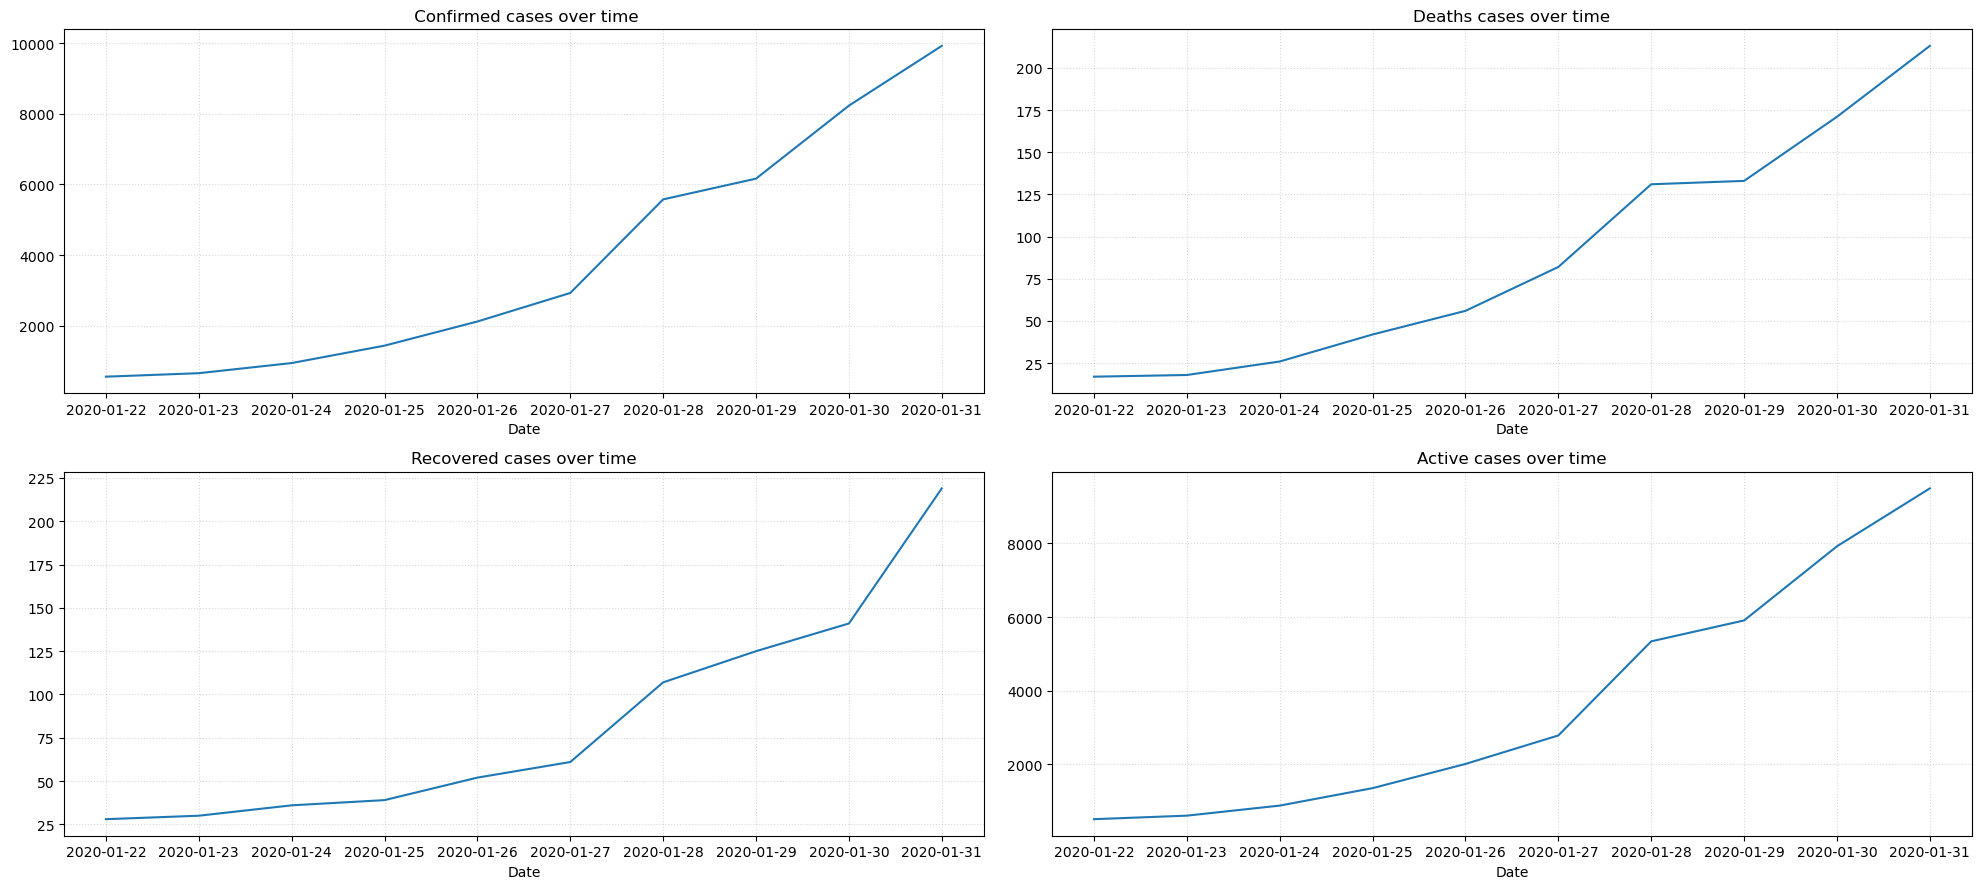

In [17]:

confirmed_weekly= df.groupby('Date')['Confirmed'].sum().sort_values(ascending=True).head(10)
deaths_weekly= df.groupby('Date')['Deaths'].sum().sort_values(ascending=True).head(10)
active_weekly= df.groupby('Date')['Active'].sum().sort_values(ascending=True).head(10)
Recovered_weekly= df.groupby('Date')['Recovered'].sum().sort_values(ascending=True).head(10)

plt.subplots(2,2,figsize=(20,9))


plt.subplot(2,2,1)
sns.lineplot(x=confirmed_weekly.index,y=confirmed_weekly.values)
plt.title(" Confirmed cases over time",color='black')
plt.grid(True,ls =":",alpha=0.3, color="grey")


plt.subplot(2,2,2)
sns.lineplot(x=deaths_weekly.index,y=deaths_weekly.values)
plt.title("Deaths cases over time",color='black')
plt.grid(True,ls =":",alpha=0.3, color="grey")



plt.subplot(2,2,3)
sns.lineplot(x=Recovered_weekly.index,y=Recovered_weekly.values)
plt.title("Recovered cases over time",color='black')
plt.grid(True,ls =":",alpha=0.3, color="grey")




plt.subplot(2,2,4)
sns.lineplot(x=active_weekly.index,y=active_weekly.values)
plt.title("Active cases over time",color='black')
plt.grid(True,ls =":",alpha=0.3, color="grey")

plt.tight_layout()

plt.show()

The analysis shows that confirmed , active, recovered and deaths cases increased over time.Confirmed and active cases show sharp increase, while recovered cases and  Death
 cases increased gradually compared to other cases.

Visualize the correlation between numerical column.

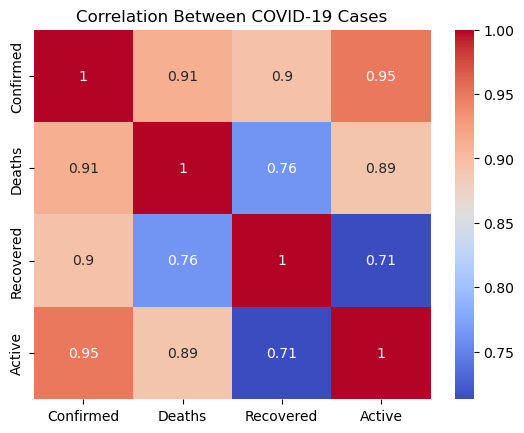

In [18]:
corr = df[['Confirmed', 'Deaths', 'Recovered', 'Active']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between COVID-19 Cases')
plt.show()

All covid -19 case variables show positive correlation with each other. The strongest relationship between  confirmed and active cases(0.95),
while the weakest is betwwen recovered and active case(0.71). 

Comparsion of all cases.

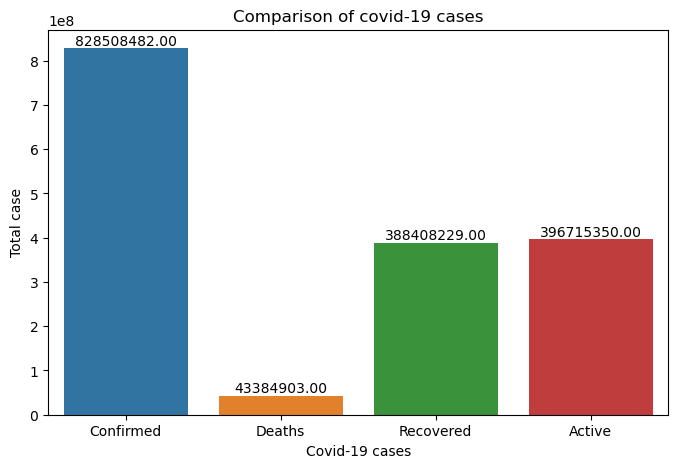

In [19]:
i = ['Confirmed', 'Deaths', 'Recovered', 'Active']
total=df[i].sum()


plt.figure(figsize=(8,5))
bar=sns.barplot(x=total.index,y=total.values,hue=total.index)
plt.xlabel("Covid-19 cases")
plt.ylabel("Total case")
plt.title("Comparison of covid-19 cases")
for container in bar.containers:
    plt.bar_label(container,fmt="%.2f")
plt.show()

* Confirmed case is the highest , active cases are lower than confirmed cases,recovered cases are lower than active cases , and deaths are the lowest.
* Confirmed > Active > Recovered > Deaths.

COVID-19 Cases by WHO Region

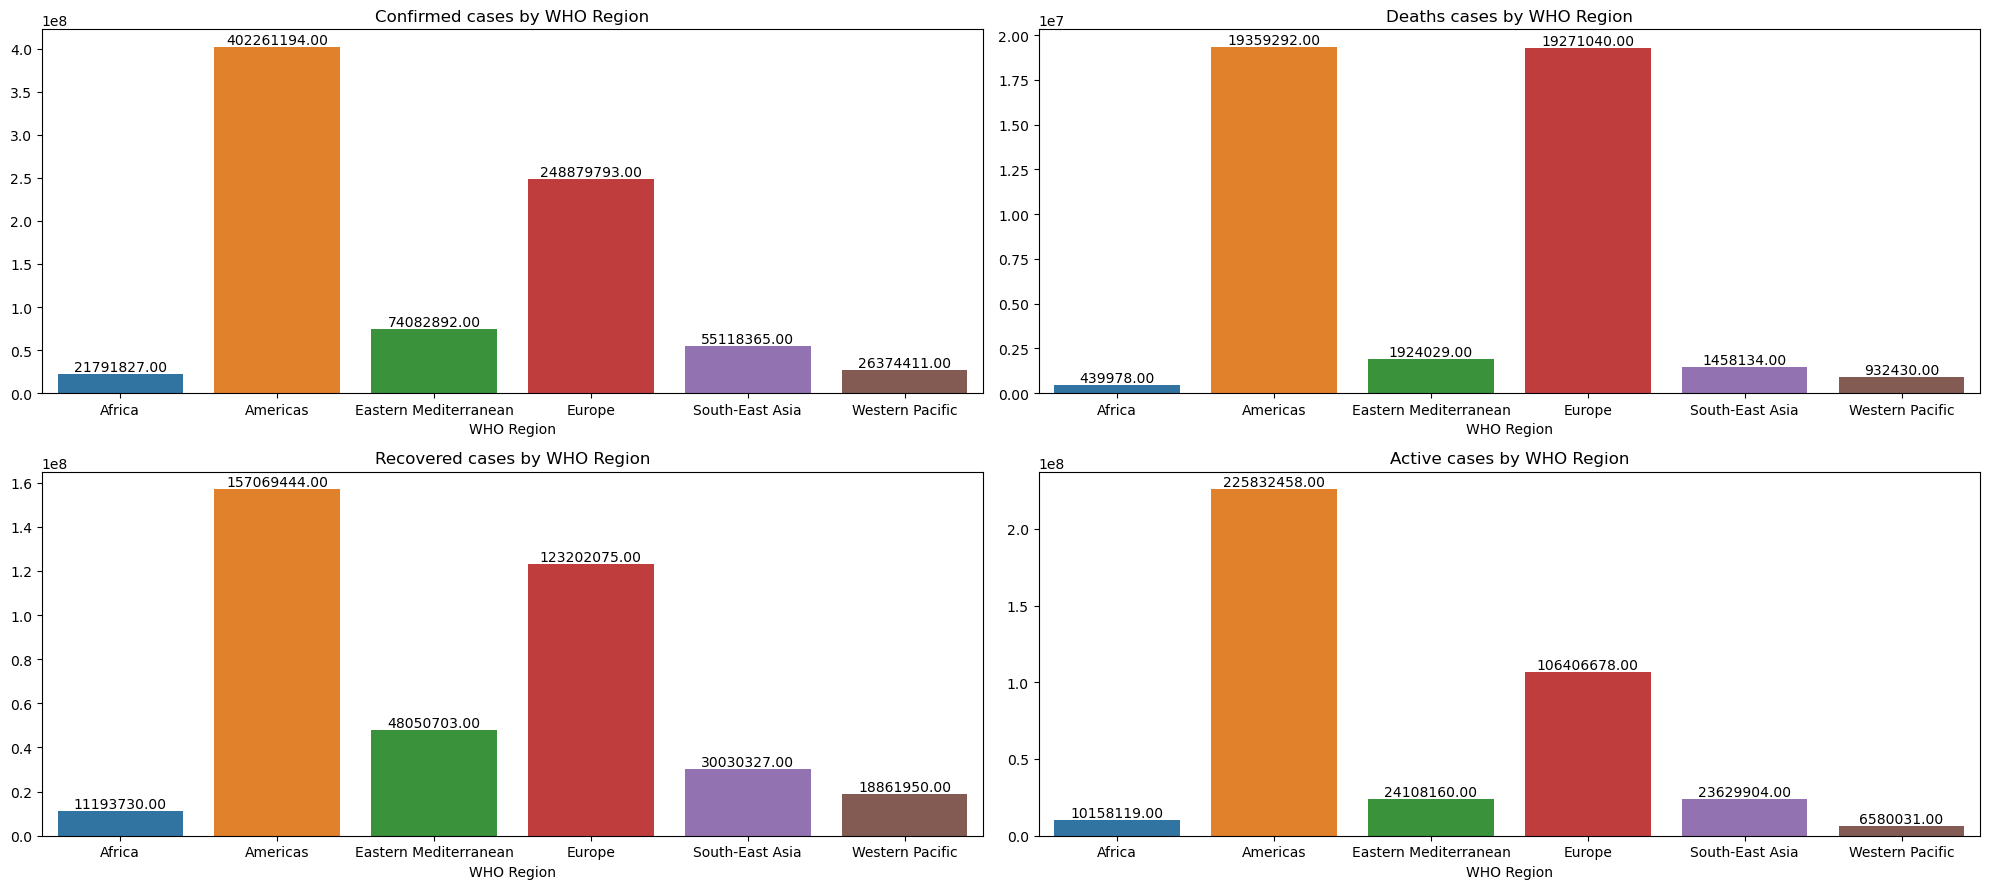

In [20]:

confirmed= df.groupby('WHO Region')['Confirmed'].sum()
deaths= df.groupby('WHO Region')['Deaths'].sum()
active= df.groupby('WHO Region')['Active'].sum()
Recovered= df.groupby('WHO Region')['Recovered'].sum()

plt.subplots(2,2,figsize=(20,9))


plt.subplot(2,2,1)
bar= sns.barplot(x=confirmed.index,y=confirmed.values,hue=confirmed.index)
plt.title("Confirmed cases by WHO Region",color='black')
for container in bar.containers:
    plt.bar_label(container,fmt="%.2f")

plt.subplot(2,2,2)
bar=sns.barplot(x=deaths.index,y=deaths.values,hue=deaths.index)
plt.title("Deaths cases by WHO Region",color='black')
for container in bar.containers:
    plt.bar_label(container,fmt="%.2f")


plt.subplot(2,2,3)
bar=sns.barplot(x=Recovered.index,y=Recovered.values,hue=Recovered.index)
plt.title("Recovered cases by WHO Region",color='black')
for container in bar.containers:
    plt.bar_label(container,fmt="%.2f")



plt.subplot(2,2,4)
bar=sns.barplot(x=active.index,y=active.values,hue=active.index)
plt.title("Active cases by WHO Region",color='black')
for container in bar.containers:
    plt.bar_label(container,fmt="%.2f")

plt.tight_layout()

plt.show()

The analysis shows that the America have the highest confirmed, death, recovered, and active cases, While Africa has the lowest cases.Europe has the second-highest  confirmed, death, recovered, and active cases,

Visualize the percentage of confirmed cases by WHO Region 

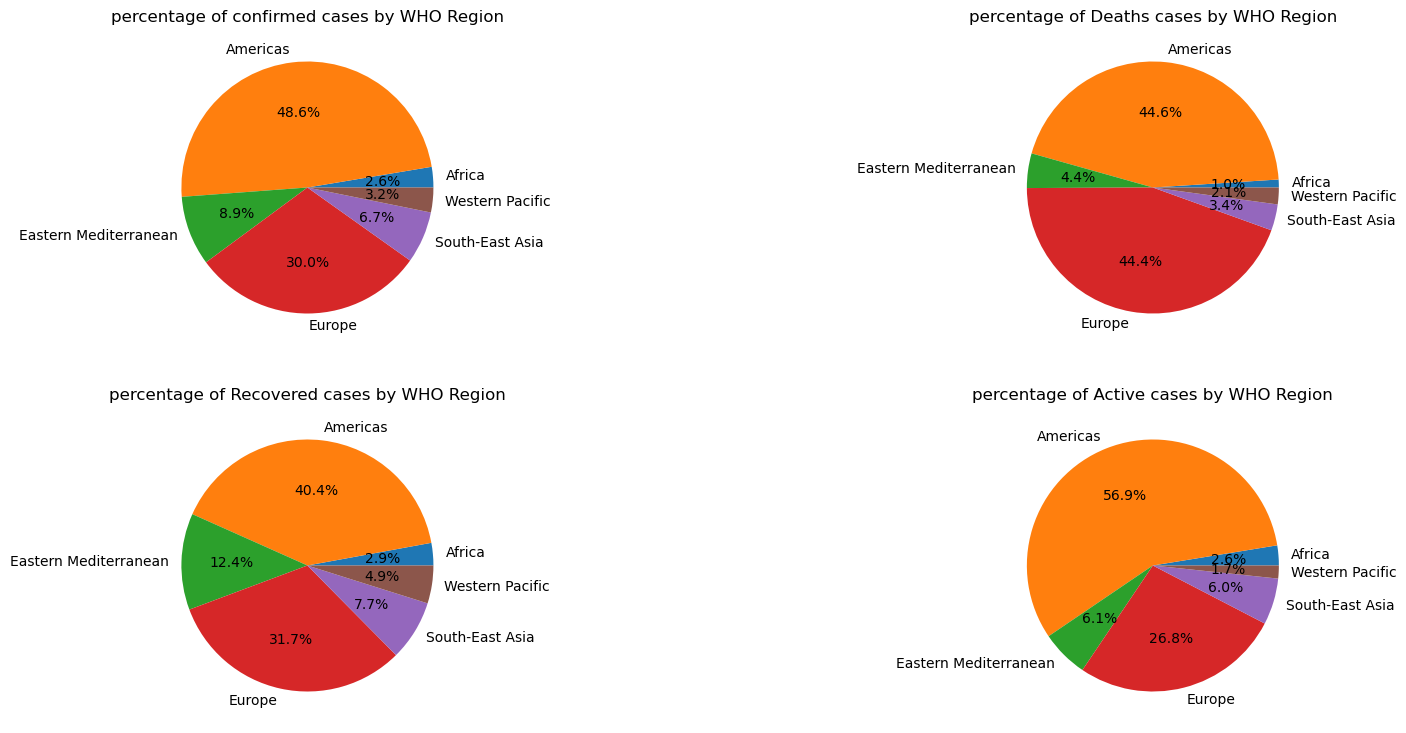

In [21]:

Confirmed_cases= df.groupby('WHO Region')['Confirmed'].sum()
Deaths_cases= df.groupby('WHO Region')['Deaths'].sum()
Recovered_cases= df.groupby('WHO Region')['Recovered'].sum()
Active_cases= df.groupby('WHO Region')['Active'].sum()


plt.subplots(2,2,figsize=(20,9))

plt.subplot(2,2,1)
plt.pie(Confirmed_cases, labels=Confirmed_cases.index,autopct="%1.1f%%")
plt.title("percentage of confirmed cases by WHO Region")

plt.subplot(2,2,2)
plt.pie(Deaths_cases, labels=Deaths_cases.index,autopct="%1.1f%%")
plt.title("percentage of Deaths cases by WHO Region")

plt.subplot(2,2,3)
plt.pie(Recovered_cases, labels=Recovered_cases.index,autopct="%1.1f%%")
plt.title("percentage of Recovered cases by WHO Region")

plt.subplot(2,2,4)
plt.pie(Active_cases, labels=Active_cases.index,autopct="%1.1f%%")
plt.title("percentage of Active cases by WHO Region")

plt.show()


The analysis shows that the America have the highest share of confirmed case ,deaths case, recovered case and active case followed by Europe and Africa has the lowest share.

Visualize the Geographical distribution of Confirmed cases

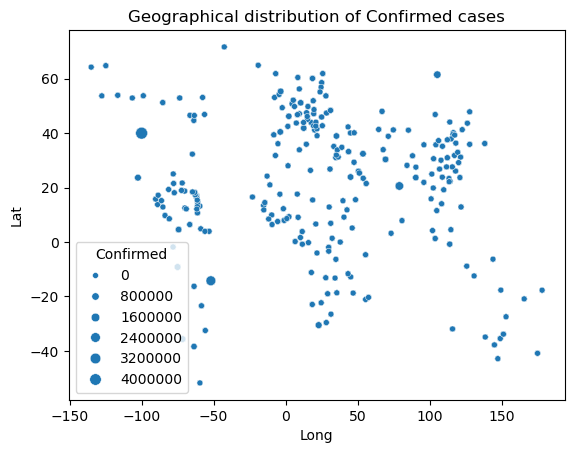

In [22]:
sns.scatterplot(data=df,x='Long',y='Lat',size='Confirmed')
plt.title("Geographical distribution of Confirmed cases")
plt.show()

Large point represent locations with higher confirmed cases, While smaller points represent locations with fewer confirmed cases.

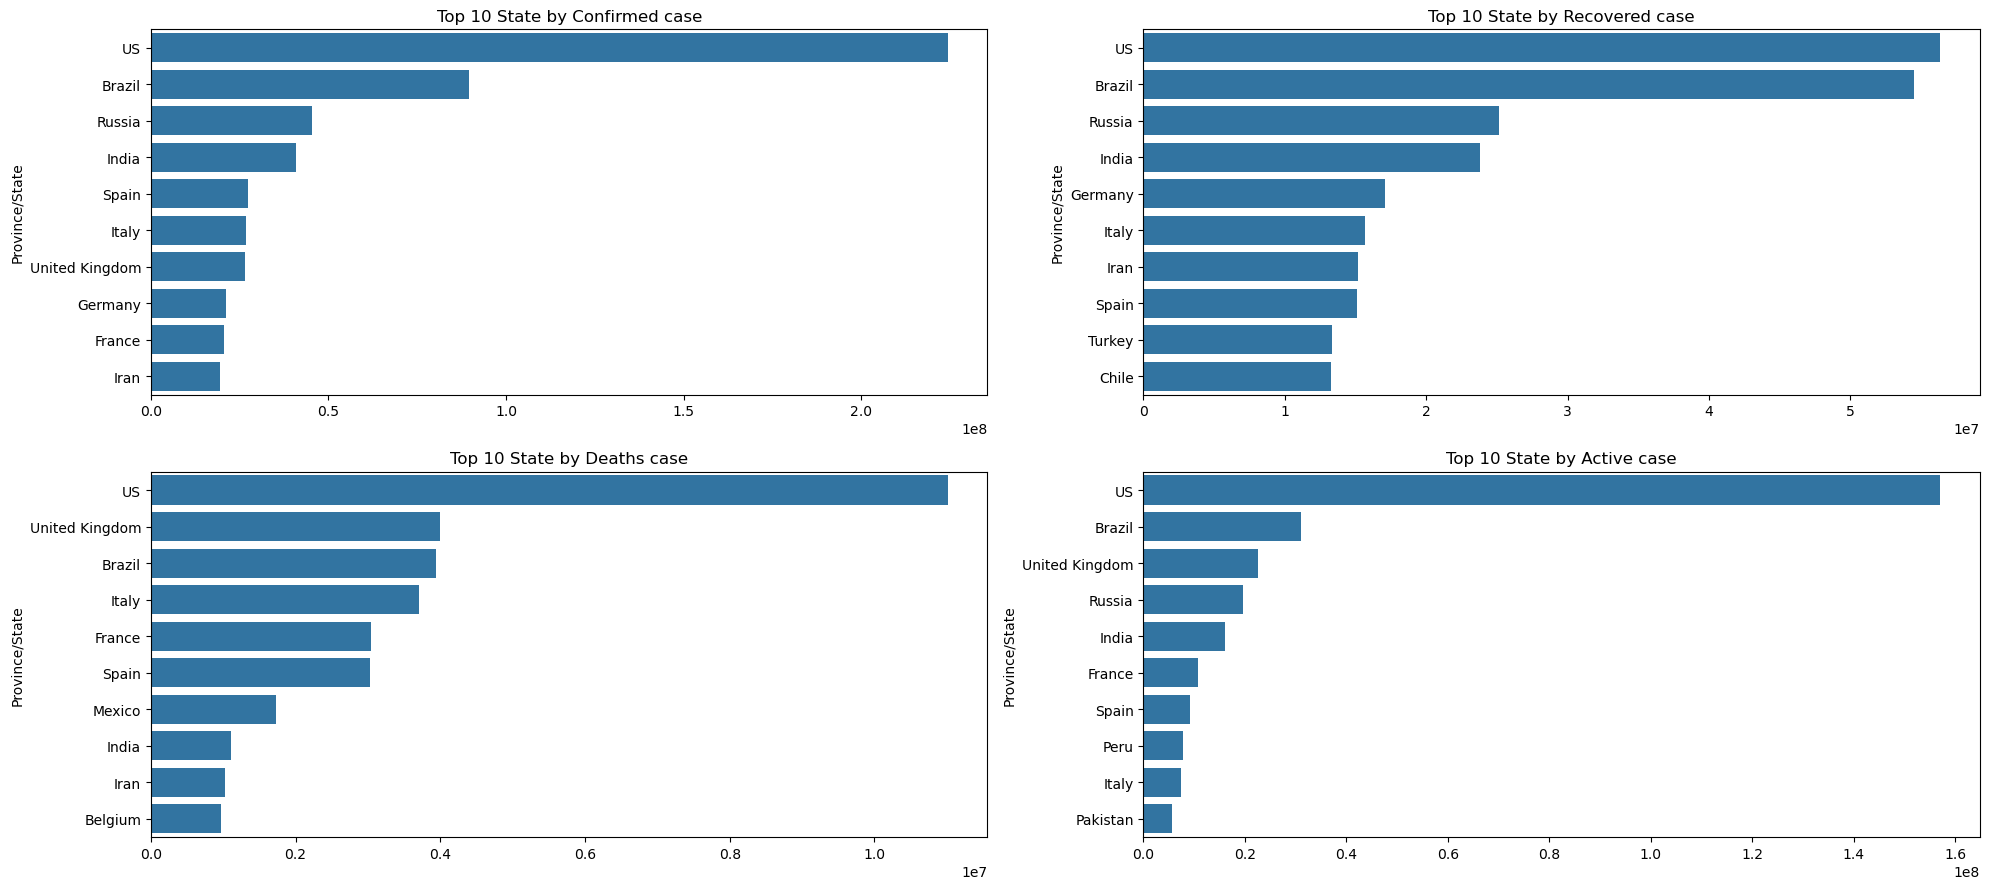

In [23]:
top10_confirmed= df.groupby('Province/State')['Confirmed'].sum().sort_values(ascending=False).head(10)
top10_deaths= df.groupby('Province/State')['Deaths'].sum().sort_values(ascending=False).head(10)
top10_active= df.groupby('Province/State')['Active'].sum().sort_values(ascending=False).head(10)
top10_Recovered= df.groupby('Province/State')['Recovered'].sum().sort_values(ascending=False).head(10)


plt.subplots(2,2,figsize=(20,9))


plt.subplot(2,2,1)
sns.barplot(x=top10_confirmed.values,y=top10_confirmed.index)
plt.title("Top 10 State by Confirmed case",color='black')


plt.subplot(2,2,2)
sns.barplot(x=top10_Recovered.values,y=top10_Recovered.index)
plt.title("Top 10 State by Recovered case",color='black')


plt.subplot(2,2,3)
sns.barplot(x=top10_deaths.values,y=top10_deaths.index)
plt.title("Top 10 State by Deaths case",color='black')



plt.subplot(2,2,4)
sns.barplot(x=top10_active.values,y=top10_active.index)
plt.title("Top 10 State by Active case",color='black')

plt.tight_layout()

plt.show()

The analysis show that the USA has the highest confirmed case, recovered case, deaths case and active case among the top 10 countries.
Brazil also has a high number of confirmed, recovered and active cases. However, the ranking for deaths differ from confirmed case with the united
kingdom ranking second in deaths.(Missing State/Region values were filled with country names, so some entries representcountries instead of actual states or regions.)